# Notebook for constructing age models for Michipicoten Island Formation

In [1]:
using Pkg
Pkg.activate("../")
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

  Activating project at `~/Github/APWP_StratModels/code`


plot_posterior_paths (generic function with 1 method)

## Michipicoten Island Formation

- We define the bottom of the section to be the base of the Quebect Harbor andesite which is above the West Sand Bay tuff
- We define the top of the section to be the Davieaux Island rhyolite

In [2]:
Michipicoten_Name = ("West Sand Bay Member tuff", "Davieaux Island rhyolite") # Et cetera
Michipicoten_Age           = [ 1084.35, 1083.52] # Measured ages
Michipicoten_Age_sigma     = [ 0.2/2,   0.23/2] # Measured 1-σ uncertainties
Michipicoten_Height        = [ 0,     1006] # Depths below surface should be negative
Michipicoten_Age_Sidedness = [0, 0] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

Michipicoten_Path = "../../data/age_models_output/Michipicoten" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
Michipicoten_section = make_ChronAgeData(Michipicoten_Name, Michipicoten_Age, Michipicoten_Age_sigma, Michipicoten_Height, Michipicoten_Age_Sidedness, Michipicoten_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{2}(("West Sand Bay Member tuff", "Davieaux Island rhyolite"), [0.0, 1006.0], [0.01, 0.01], [1084.35, 1083.52], [0.1, 0.115], [NaN, NaN], [NaN, NaN], [NaN, NaN], [NaN, NaN], [0.0, 0.0], [0.0, 0.0], [#undef, #undef], (:Chronometer, :Chronometer), [NaN NaN; NaN NaN; … ; NaN NaN; NaN NaN], "../../data/age_models_output/Michipicoten", 2, "Ma", "m", :cdf)

In [3]:
Michipicoten_age_model_config, Michipicoten_age_model_mdl, Michipicoten_age_model_agedist, Michipicoten_age_model_lldist = run_age_model(Michipicoten_section, 2, 0.2, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:28
┌ Info: Burn-in: 706000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 706000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/zKIt8/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:00


(StratAgeModelConfiguration(2.0, 706000, 1000, 706, 0.2), StratAgeModel([0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0  …  988.0, 990.0, 992.0, 994.0, 996.0, 998.0, 1000.0, 1002.0, 1004.0, 1006.0], [1084.3617284121733, 1084.359913684178, 1084.3590306460533, 1084.3575679319, 1084.3562464806962, 1084.3546813497571, 1084.352458456694, 1084.3508398225506, 1084.348685940802, 1084.3468019405898  …  1083.5232027266752, 1083.5208245281262, 1083.5200777848263, 1083.5181482949456, 1083.5163953920248, 1083.5131588715667, 1083.511286349277, 1083.5086769190661, 1083.507003367619, 1083.5048246240767], [0.0829936228401207, 0.08409113788999974, 0.08435014016493901, 0.08520261319932526, 0.0855758567773641, 0.08710132232865618, 0.08807735065849721, 0.0886612340854058, 0.09105485524044855, 0.09203588476086884  …  0.10344753274718285, 0.10164571591203475, 0.10128972825723069, 0.09967358252042455, 0.09800809372646956, 0.09543516840055927, 0.09444398291326608, 0.09286172586596808, 0.0919034465056644

### posterior summary age model

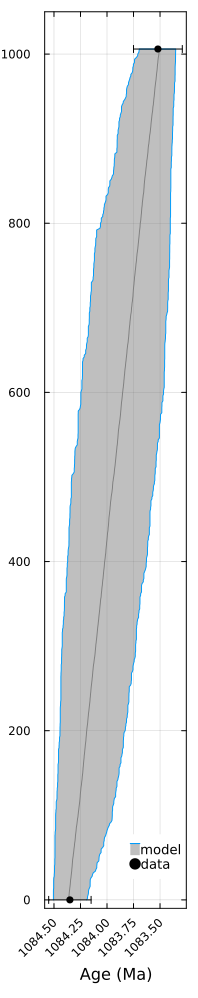

In [4]:
Michipicoten_age_model = plot_age_model(Michipicoten_section, Michipicoten_age_model_mdl, save_figure=false)
plot!(ylim=(-10, 1050))
# show xticks 
yticks!([0, 200, 400, 600, 800, 1000])
savefig(Michipicoten_age_model, Michipicoten_section.Path*"_AgeDepthModel.pdf")
display(Michipicoten_age_model)

### example posterior accumulation models

In [11]:
function plot_accumulation_model(
    section,
    config,
    mdl,
    agedist;
    binwidth = 2,
    stepfrac = 0.1,   # fraction of binwidth between windows
    save_figure = false
)

    # ------------------------------------------------------------------
    # 1. Define sliding window geometry
    # ------------------------------------------------------------------
    agemin, agemax = extrema(mdl.Age)
    halfw = binwidth / 2
    Δt = binwidth * stepfrac
    println("agemin: $agemin, agemax: $agemax, halfw: $halfw, Δt: $Δt")
    centers = collect(range(agemin + halfw, agemax - halfw, step = Δt))
    println("Number of windows: $(length(centers))")
    if length(centers) < 1
        @warn "Age range too short for accumulation-rate estimation"
        return plot()
    end

    nwin = length(centers)
    nstep = config.nsteps

    # ------------------------------------------------------------------
    # 2. Allocate result array
    # ------------------------------------------------------------------
    dhdt_dist = Array{Float64}(undef, nwin, nstep)

    # ------------------------------------------------------------------
    # 3. Sliding-window rate calculation
    # ------------------------------------------------------------------
    @time for i in 1:nstep
        H = reverse(mdl.Height)
        T = reverse(agedist[:, i])

        for (j, tc) in enumerate(centers)
            t1 = tc - halfw
            t2 = tc + halfw

            h1 = linterp1(T, H, t1)
            h2 = linterp1(T, H, t2)

            dhdt_dist[j, i] = abs(h2 - h1) / binwidth
        end
    end

    # ------------------------------------------------------------------
    # 4. Ensemble statistics
    # ------------------------------------------------------------------
    dhdt_mean = nanmean(dhdt_dist, dims = 2)
    dhdt_med  = nanmedian(dhdt_dist, dims = 2)
    dhdt_16p  = nanpctile(dhdt_dist, 15.865, dims = 2)
    dhdt_84p  = nanpctile(dhdt_dist, 84.135, dims = 2)

    # ------------------------------------------------------------------
    # 5. Plot
    # ------------------------------------------------------------------
    hdl = plot(
        centers,
        dhdt_mean,
        label = "Mean",
        color = :black,
        linewidth = 2
    )

    plot!(
        hdl,
        [centers; reverse(centers)],
        [dhdt_16p; reverse(dhdt_84p)],
        fill = (0, 0.5, :darkblue),
        linealpha = 0,
        label = "68% CI"
    )

    plot!(
        hdl,
        centers,
        dhdt_med,
        label = "Median",
        color = :grey,
        linewidth = 1
    )

    plot!(
        hdl,
        xlabel = "Age ($(section.Age_Unit))",
        ylabel = "Emplacement Rate",
        framestyle = :box,
        fg_color_legend = :white,
        xflip = true
    )

    if save_figure
        savefig(hdl, section.Path * "DepositionRateModel.pdf")
    end

    return hdl
end

plot_accumulation_model (generic function with 1 method)

agemin: 1083.5048246240767, agemax: 1084.3617284121733, halfw: 0.1, Δt: 0.020000000000000004
Number of windows: 33
  0.027381 seconds (9.00 k allocations: 11.902 MiB, 12.73% gc time)


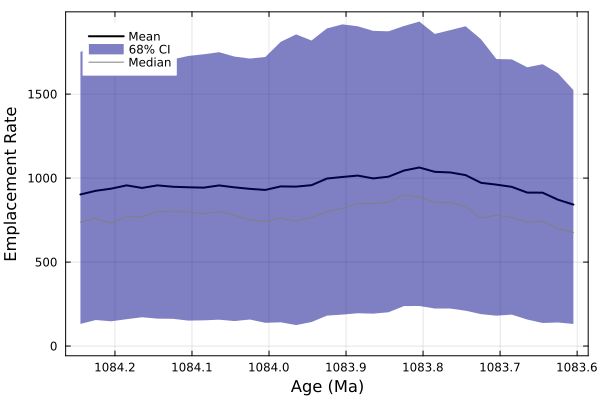

In [13]:
plot_accumulation_model(Michipicoten_section, Michipicoten_age_model_config, Michipicoten_age_model_mdl, Michipicoten_age_model_agedist, binwidth=0.2,save_figure=false)


### example posterior age models

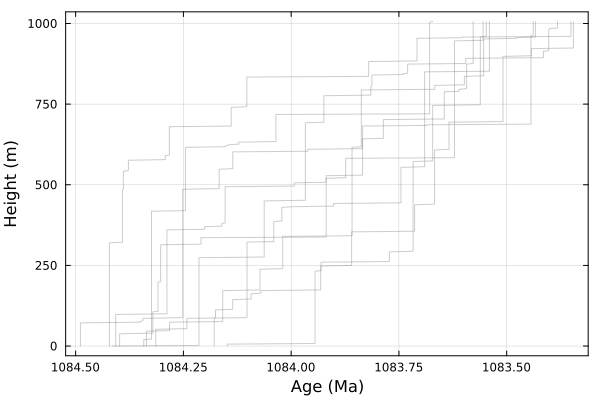

In [6]:
plot_posterior_paths(Michipicoten_section, Michipicoten_age_model_agedist, Michipicoten_age_model_mdl)

## save the age models to a file

In [7]:
Michipicoten_age_model_agedist

504×1000 Matrix{Float64}:
 1084.38  1084.34  1084.36  1084.46  …  1084.5   1084.51  1084.27  1084.49
 1084.38  1084.34  1084.36  1084.46     1084.5   1084.51  1084.22  1084.49
 1084.38  1084.34  1084.36  1084.46     1084.5   1084.51  1084.22  1084.49
 1084.38  1084.34  1084.36  1084.46     1084.5   1084.51  1084.22  1084.49
 1084.38  1084.34  1084.36  1084.46     1084.45  1084.51  1084.22  1084.49
 1084.38  1084.34  1084.36  1084.46  …  1084.45  1084.51  1084.22  1084.49
 1084.38  1084.34  1084.36  1084.46     1084.45  1084.51  1084.22  1084.49
 1084.38  1084.34  1084.29  1084.46     1084.45  1084.51  1084.22  1084.49
 1084.38  1084.34  1084.29  1084.46     1084.45  1084.51  1084.22  1084.49
 1084.38  1084.34  1084.29  1084.46     1084.45  1084.51  1084.22  1084.49
    ⋮                                ⋱                             
 1083.54  1083.54  1083.52  1083.57  …  1083.66  1083.47  1083.52  1083.58
 1083.54  1083.54  1083.52  1083.57     1083.66  1083.47  1083.52  1083.58
 1083.

In [8]:
# use the mdl.height as index, agedist as the data
Michipicoten_age_models_df = DataFrame(hcat(Michipicoten_age_model_mdl.Height, Michipicoten_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(Michipicoten_age_models_df, Dict(:x1 => "height"))
Michipicoten_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,0.0,1084.38,1084.34,1084.36,1084.46,1084.41,1084.3,1084.31,1084.38,1084.33,1084.38,1084.28,1084.39,1084.36,1084.37,1084.43,1084.27,1084.37,1084.23,1084.41,1084.44,1084.43,1084.24,1084.44,1084.37,1084.37,1084.29,1084.22,1084.43,1084.44,1084.26,1084.37,1084.35,1084.45,1084.34,1084.31,1084.22,1084.45,1084.32,1084.29,1084.49,1084.43,1084.41,1084.33,1084.33,1084.4,1084.21,1084.26,1084.38,1084.44,1084.33,1084.34,1084.52,1084.5,1084.39,1084.36,1084.33,1084.33,1084.47,1084.3,1084.4,1084.43,1084.41,1084.43,1084.41,1084.25,1084.41,1084.39,1084.24,1084.48,1084.34,1084.42,1084.36,1084.29,1084.25,1084.32,1084.46,1084.45,1084.45,1084.38,1084.45,1084.46,1084.43,1084.38,1084.41,1084.4,1084.41,1084.25,1084.42,1084.08,1084.48,1084.25,1084.44,1084.33,1084.25,1084.31,1084.37,1084.49,1084.38,1084.34,⋯
2,2.0,1084.38,1084.34,1084.36,1084.46,1084.41,1084.3,1084.31,1084.38,1084.33,1084.38,1084.28,1084.39,1084.36,1084.37,1084.43,1084.27,1084.37,1084.23,1084.41,1084.44,1084.43,1084.24,1084.44,1084.37,1084.37,1084.29,1084.22,1084.43,1084.44,1084.26,1084.37,1084.32,1084.45,1084.34,1084.31,1084.22,1084.45,1084.32,1084.29,1084.49,1084.43,1084.41,1084.33,1084.33,1084.4,1084.21,1084.26,1084.38,1084.4,1084.33,1084.34,1084.52,1084.5,1084.39,1084.36,1084.33,1084.33,1084.47,1084.3,1084.4,1084.43,1084.41,1084.43,1084.41,1084.25,1084.41,1084.39,1084.24,1084.47,1084.34,1084.42,1084.36,1084.29,1084.25,1084.32,1084.46,1084.45,1084.45,1084.38,1084.45,1084.46,1084.43,1084.38,1084.41,1084.4,1084.41,1084.25,1084.42,1084.08,1084.48,1084.25,1084.44,1084.33,1084.25,1084.31,1084.37,1084.49,1084.08,1084.34,⋯
3,4.0,1084.38,1084.34,1084.36,1084.46,1084.41,1084.3,1084.31,1084.38,1084.33,1084.38,1084.28,1084.39,1084.36,1084.37,1084.43,1084.27,1084.37,1084.23,1084.41,1084.44,1084.43,1084.24,1084.44,1084.37,1084.37,1084.29,1084.22,1084.43,1084.44,1084.26,1084.37,1084.32,1084.45,1084.34,1084.31,1084.22,1084.45,1084.32,1084.29,1084.49,1084.43,1084.41,1084.33,1084.33,1084.4,1084.21,1084.26,1084.38,1084.4,1084.33,1084.34,1084.52,1084.5,1084.39,1084.36,1084.33,1084.33,1084.47,1084.3,1084.4,1084.43,1084.41,1084.43,1084.41,1084.25,1084.41,1084.39,1084.24,1084.47,1084.34,1084.38,1084.36,1084.29,1084.25,1084.24,1084.46,1084.45,1084.45,1084.38,1084.45,1084.46,1084.43,1084.38,1084.41,1084.4,1084.41,1084.25,1084.42,1084.08,1084.48,1084.25,1084.44,1084.33,1084.25,1084.31,1084.37,1084.49,1084.08,1084.34,⋯
4,6.0,1084.38,1084.34,1084.36,1084.46,1084.41,1084.3,1084.31,1084.38,1084.33,1084.38,1084.28,1084.39,1084.27,1084.37,1084.43,1084.27,1084.37,1084.23,1084.41,1084.44,1084.43,1084.24,1084.44,1084.37,1084.37,1084.29,1084.22,1084.43,1084.44,1084.25,1084.36,1084.23,1084.45,1084.34,1084.31,1084.22,1084.45,1084.32,1084.29,1084.49,1084.43,1084.41,1084.33,1084.33,1084.4,1084.21,1084.26,1084.38,1084.4,1084.33,1084.34,1084

In [9]:
# write the DataFrame to a csv file
CSV.write(Michipicoten_section.Path*"_posterior_ages.csv", Michipicoten_age_models_df)

"../../data/age_models_output/Michipicoten_posterior_ages.csv"